<h4 style="color:orange;"> 1. Import Libraries </h4>

In [12]:
# Basic libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

# Evaluation library
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
## Updated wrapper
from scikeras.wrappers import KerasClassifier

<h4 style="color:orange;"> 2. Import Dataset </h4>

In [2]:
fashion_train=pd.read_csv("fashion-mnist_train.csv")
fashion_test=pd.read_csv("fashion-mnist_test.csv")

<h4 style="color:orange;"> 3. Checking the data </h4>

In [6]:
fashion_train.shape

(60000, 785)

<h4 style="color:orange;"> 4. Train & Test split </h4>

In [4]:
X_train_fashion=fashion_train.drop('label',axis=1)
y_train_fashion=fashion_train['label']
X_test_fashion=fashion_test.drop('label',axis=1)
y_test_fashion=fashion_test['label']

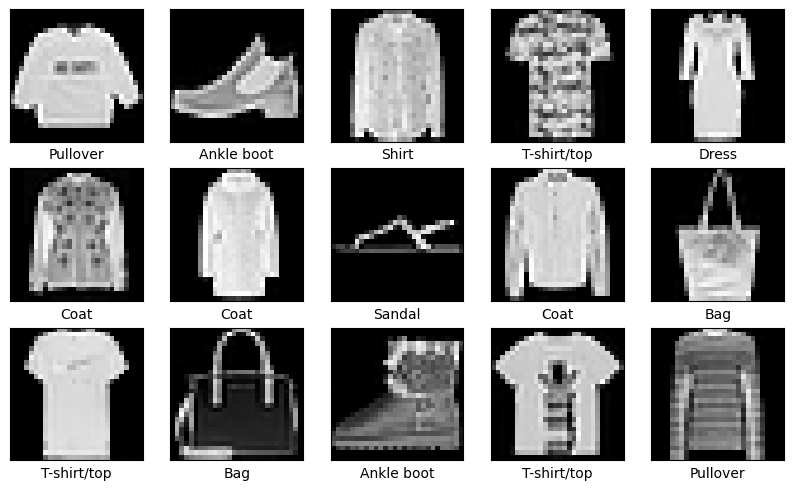

In [5]:
x_train_reshape=X_train_fashion.values.reshape(-1,28,28)
x_test_reshape=X_test_fashion.values.reshape(-1,28,28)

# Names of clothing accessories in order
col_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
             'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualizing the images
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(15):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])

plt.show()

<h4 style="color:orange;"> 5. Data preprocessing - Output </h4>

In [7]:
# Encoding fashion MNIST lables
y_train_fashion = to_categorical(y_train_fashion, num_classes=10)

y_test_fashion = to_categorical(y_test_fashion, num_classes=10)

In [8]:
y_train_fashion[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

<h4 style="color:orange;"> 6. Model creation </h4>

In [13]:
# Creating base neural network
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax'),
])

# Compiling the model
model.compile(loss = "categorical_crossentropy", 
              optimizer = "adam", 
              metrics = ['accuracy'])

# Fitting the model
history = model.fit(X_train_fashion, y_train_fashion, batch_size=100, epochs=10, validation_data=(X_test_fashion, y_test_fashion))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.6229 - loss: 1.1269 - val_accuracy: 0.8242 - val_loss: 0.5380
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7510 - loss: 0.7359 - val_accuracy: 0.8334 - val_loss: 0.4903
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7697 - loss: 0.6722 - val_accuracy: 0.8502 - val_loss: 0.4469
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7835 - loss: 0.6446 - val_accuracy: 0.8516 - val_loss: 0.4372
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7898 - loss: 0.6284 - val_accuracy: 0.8498 - val_loss: 0.4617
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7981 - loss: 0.6011 - val_accuracy: 0.8622 - val_loss: 0.4669
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8081 - loss: 0.5806 - val_accuracy: 0.8594 - val_loss: 0.4277
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8078 - loss: 0.5720 - val_acc

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           3,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 314,688 (1.20 MB)

 Trainable params: 104,778 (409.29 KB)

 Non-trainable params: 352 (1.38 KB)

 Optimizer params: 209,558 (818.59 KB)

In [15]:
test_loss_fashion, test_acc_fashion = model.evaluate(X_test_fashion, y_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8562 - loss: 0.4068


In [16]:
print('Fashion MNIST Test Accuracy:', round(test_acc_fashion, 4))

Fashion MNIST Test Accuracy: 0.8562


<h4 style="color:darkblue;"> 6. Prediction </h4>

In [17]:
# Predicting the labels - Fashion
y_predict_fash = model.predict(X_test_fashion)
y_predict_fash = np.argmax(y_predict_fash, axis=1)
y_test_fash_eval = np.argmax(y_test_fashion, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<h4 style="color:darkblue;"> 7. Evaluation </h4>

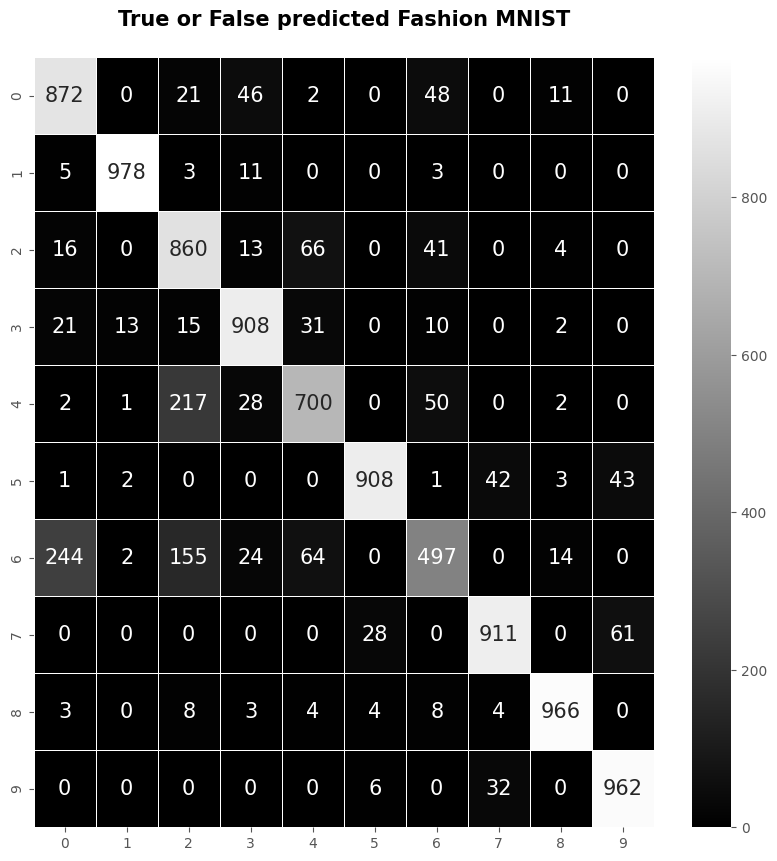

In [18]:
# Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_fash_eval, y_predict_fash)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size':15}, linewidths=0.5, fmt="d", cmap="gray")
plt.title('True or False predicted Fashion MNIST\n', fontweight='bold', fontsize=15)
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test_fash_eval, y_predict_fash))

              precision    recall  f1-score   support

           0       0.75      0.87      0.81      1000
           1       0.98      0.98      0.98      1000
           2       0.67      0.86      0.75      1000
           3       0.88      0.91      0.89      1000
           4       0.81      0.70      0.75      1000
           5       0.96      0.91      0.93      1000
           6       0.76      0.50      0.60      1000
           7       0.92      0.91      0.92      1000
           8       0.96      0.97      0.97      1000
           9       0.90      0.96      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000



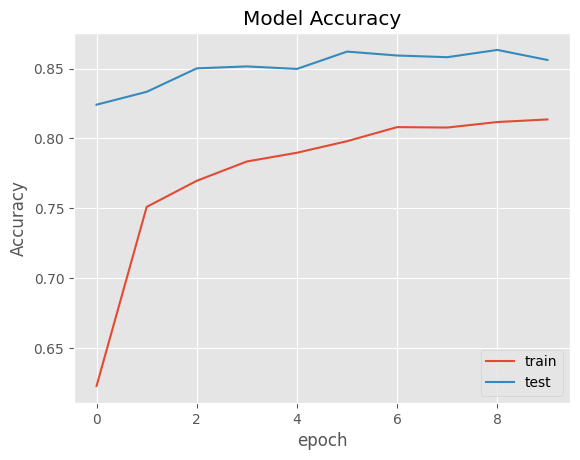

In [20]:
# Summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

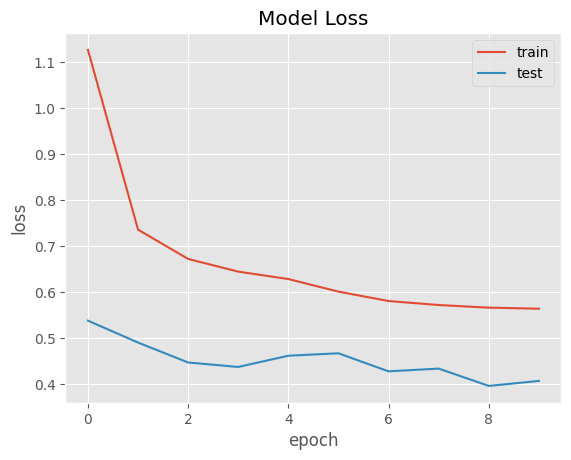

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

<h4 style="color:darkblue;"> 8. Test & display results </h4>

In [22]:
# tf.expand_dims(X_test_fashion[0])
y_predict_single = model.predict(X_test_fashion.loc[[0],:].values)

y_predicts_single = np.argmax(y_predict_single, axis=1)  
# Here we get the index of maximum value in the encoded vector

y_test_fashion_eval = np.argmax(y_test_fashion, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


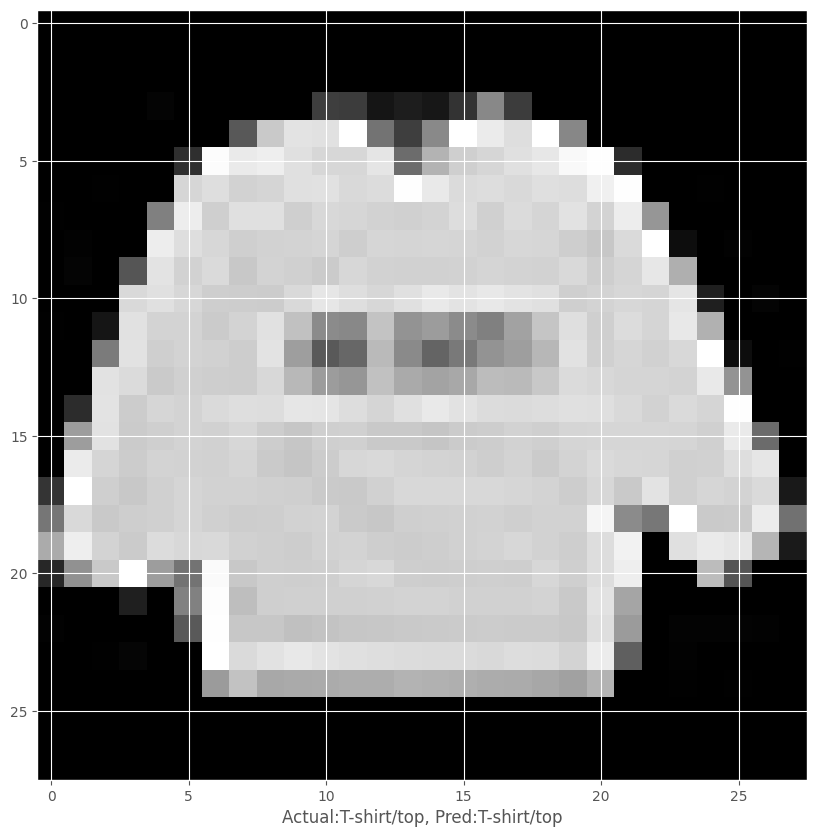

In [24]:
# Names of numbers in the dataset in order
col_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
             'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualizing the digits
plt.figure(figsize=(10,10))

plt.imshow(x_train_reshape[0], cmap='gray')

plt.xlabel('Actual:{}, Pred:{}'.format(
    col_names[np.argmax(y_test_fashion[0])],  # [2] → selects the 3rd test image (we are checking prediction for that specific image)
    col_names[y_predicts_single[0]]         # [0] → we take the first (and only) prediction result for that single image
))

plt.show()